# Negative Binomial Regression for Overdispersed Count Data
### A worked example: predicting engagement from visual content features

**Author:** Khatereh Shafaat
**Contact:** [LinkedIn](https://www.linkedin.com/in/khatereh-shafaat-073006111/) &nbsp;|&nbsp; shafaatkhatereh@gmail.com

---

## Overview

Count outcomes such as views, likes, shares, or clicks are almost never nicely
distributed — they're skewed, bounded at zero, and usually **overdispersed**
(their variance is much larger than their mean). Ordinary least squares (OLS)
regression is the wrong tool here, and even a plain Poisson model often breaks
down for real engagement data.

This notebook walks through a full, reproducible workflow for modeling this
kind of data, using the same methodology I used in my graduate research on
visual content and audience engagement:

1. Simulate a realistic, overdispersed count dataset
2. Diagnose skewness and decide on transformations
3. Mean-center continuous predictors for interpretable interaction effects
4. Compare Poisson vs. Negative Binomial models with a likelihood-ratio test
5. Fit the final Negative Binomial model with cluster-robust standard errors
6. Visualize interaction effects
7. Run a turning-point (Lind & Mehlum, 2010) test for U-shaped relationships

**Note on data:** to keep this notebook shareable, all data below is
synthetically generated with `numpy.random`, not real research data. The
statistical workflow, however, mirrors a real applied research pipeline.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import skew, chi2, norm
import warnings

warnings.filterwarnings("ignore")

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["font.size"] = 11


## 2. Simulate the dataset

We simulate 2,000 "content items" (think: social media posts or video
thumbnails), each with a few visual and contextual features, and a
count-valued outcome (`engagement`) with a true negative-binomial-like
data-generating process — including a quadratic (U-shaped) effect and an
interaction term, so the later diagnostics have something real to recover.


In [2]:
n = 2000

df = pd.DataFrame({
    "content_id": np.arange(1, n + 1),
    "group_id": np.random.randint(1, 121, size=n),          # e.g. "organization" cluster
    "face_presence": np.random.binomial(1, 0.55, size=n),
    "text_area": np.random.gamma(shape=2.0, scale=6.0, size=n),        # skewed, like % area
    "color_saturation": np.random.normal(50, 15, size=n).clip(0, 100),
    "color_complexity": np.random.normal(5, 2, size=n).clip(0, None),
    "emotion_score": np.random.normal(0, 1, size=n),         # standardized sentiment/emotion cue
})

# ---- construct a true, overdispersed count outcome ------------------------
saturation_c = df["color_saturation"] - df["color_saturation"].mean()

linear_pred = (
    2.6
    + 0.35 * df["face_presence"]
    + 0.015 * df["text_area"]
    + 0.02 * saturation_c
    - 0.0006 * saturation_c**2          # quadratic -> turning point
    + 0.18 * df["emotion_score"]
    + 0.01 * saturation_c * df["emotion_score"]   # interaction term
)

mu = np.exp(linear_pred)
dispersion = 1.8  # negative-binomial dispersion (r = 1/alpha-ish)
df["engagement"] = np.random.negative_binomial(
    n=dispersion, p=dispersion / (dispersion + mu)
)

df.head()


,content_id,group_id,face_presence,text_area,color_saturation,color_complexity,emotion_score,engagement
0,1,103,1,1.878023,56.492668,5.645405,0.563100,27
1,2,52,0,37.358320,48.120612,5.346440,-1.605376,35
2,3,93,0,1.896538,40.963713,4.031131,0.141654,1
3,4,15,0,11.370749,61.192605,5.391472,0.218477,35
4,5,107,1,8.998340,51.751596,6.946741,1.462338,20


## 3. Exploratory checks: skewness and dispersion

Before modeling, we check two things that determine our modeling choices:

- **Skewness** of continuous predictors — guides whether to log-transform.
- **Mean vs. variance** of the outcome — tells us whether Poisson's
  equidispersion assumption (`Var(Y) = Mean(Y)`) is reasonable.


In [3]:
continuous_vars = ["text_area", "color_saturation", "color_complexity", "emotion_score"]

skew_table = pd.DataFrame({
    "skewness": [skew(df[c]) for c in continuous_vars]
}, index=continuous_vars).round(2)

print(skew_table)

print("\nOutcome mean:    ", round(df["engagement"].mean(), 2))
print("Outcome variance:", round(df["engagement"].var(), 2))
print("Variance / Mean ratio:", round(df["engagement"].var() / df["engagement"].mean(), 2))


                  skewness
text_area             1.51
color_saturation      0.01
color_complexity      0.01
emotion_score         0.03

Outcome mean:     19.06
Outcome variance: 362.14
Variance / Mean ratio: 19.0


`text_area` is right-skewed (as expected for an area/size-like variable), so
we log-transform it. The outcome's variance is far larger than its mean —
a classic sign of overdispersion, which is exactly what Negative Binomial
regression is designed to handle.


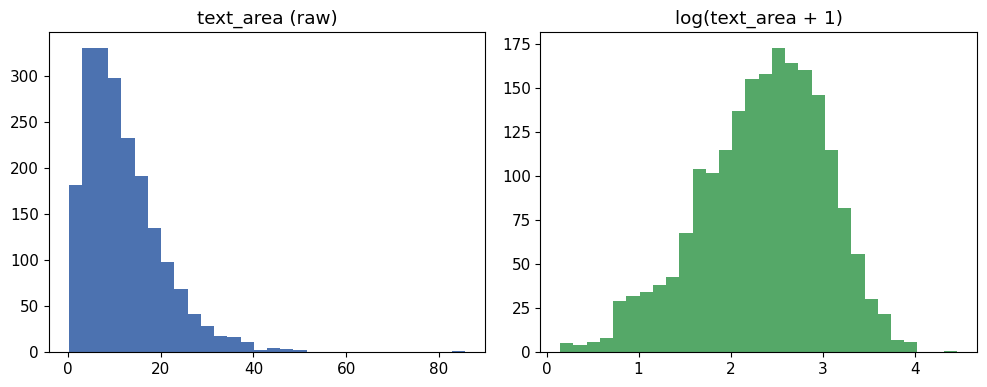

In [4]:
df["log_text_area"] = np.log1p(df["text_area"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df["text_area"], bins=30, color="#4C72B0")
axes[0].set_title("text_area (raw)")
axes[1].hist(df["log_text_area"], bins=30, color="#55A868")
axes[1].set_title("log(text_area + 1)")
plt.tight_layout()
plt.show()


## 4. Mean-centering continuous predictors

We mean-center `color_saturation` (and its square, for the quadratic term)
before modeling. This is standard practice when a model includes interaction
or polynomial terms: it keeps the linear term interpretable as "the effect
at the average level" and avoids severe multicollinearity between a variable
and its square.


In [5]:
df["saturation_c"] = df["color_saturation"] - df["color_saturation"].mean()
df["saturation_c_sq"] = df["saturation_c"] ** 2

df[["color_saturation", "saturation_c", "saturation_c_sq"]].describe().round(2)


,color_saturation,saturation_c,saturation_c_sq
count,2000.00,2000.00,2000.00
mean,50.24,0.00,230.21
std,15.18,15.18,316.92
min,0.00,-50.24,0.00
25%,40.09,-10.15,26.03
50%,50.03,-0.21,103.63
75%,60.52,10.28,309.66
max,100.00,49.76,2524.49


## 5. Poisson vs. Negative Binomial: a formal comparison

Rather than assuming Negative Binomial is the right choice, we check it:
fit both models and run a likelihood-ratio test on the NB dispersion
parameter (alpha). A large, significant LR statistic confirms the data
is overdispersed relative to Poisson.


In [6]:
formula = (
    "engagement ~ face_presence + log_text_area + saturation_c + saturation_c_sq "
    "+ emotion_score + saturation_c:emotion_score"
)

poisson_model = smf.poisson(formula=formula, data=df).fit(disp=False)
nb_model = smf.negativebinomial(formula=formula, data=df).fit(disp=False)

llf_poisson = poisson_model.llf
llf_nb = nb_model.llf
lr_stat = 2 * (llf_nb - llf_poisson)
p_value = chi2.sf(lr_stat, df=1)

print(f"Poisson log-likelihood:            {llf_poisson:.2f}")
print(f"Negative Binomial log-likelihood:  {llf_nb:.2f}")
print(f"LR statistic:                      {lr_stat:.2f}")
print(f"p-value:                           {p_value:.4g}")
print("\n=> Negative Binomial is strongly preferred." if p_value < 0.001
      else "\n=> No strong evidence against Poisson.")


Poisson log-likelihood:            -14553.29
Negative Binomial log-likelihood:  -7583.06
LR statistic:                      13940.47
p-value:                           0

=> Negative Binomial is strongly preferred.


## 6. Final model: Negative Binomial with cluster-robust standard errors

Since observations are naturally grouped (e.g., multiple content items per
organization), we cluster standard errors by `group_id`. Ignoring this
clustering would understate standard errors and inflate significance.


In [7]:
final_model = smf.negativebinomial(
    formula=formula,
    data=df
).fit(
    maxiter=400,
    method="bfgs",
    cov_type="cluster",
    cov_kwds={"groups": df["group_id"]},
    disp=False,
)

print(final_model.summary())


                     NegativeBinomial Regression Results                      
Dep. Variable:             engagement   No. Observations:                 2000
Model:               NegativeBinomial   Df Residuals:                     1993
Method:                           MLE   Df Model:                            6
Date:                Thu, 20 Aug 2026   Pseudo R-squ.:                 0.04062
Time:                        17:27:12   Log-Likelihood:                -7583.1
converged:                       True   LL-Null:                       -7904.1
Covariance Type:              cluster   LLR p-value:                1.962e-135
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      2.3426      0.086     27.248      0.000       2.174       2.511
face_presence                  0.4038      0.037     10.789      0.000       0.330 

## 7. Visualizing the interaction effect

The model includes an interaction between `saturation_c` (color intensity,
centered) and `emotion_score`. We visualize predicted engagement across the
range of saturation, at low / average / high emotion levels, holding all
other predictors at their means.


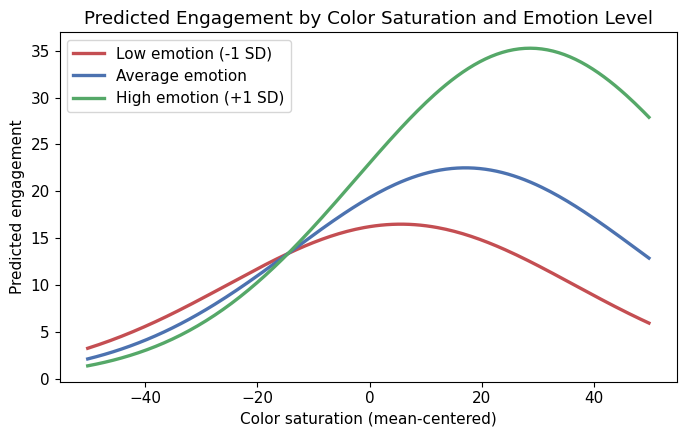

In [8]:
x = np.linspace(df["saturation_c"].min(), df["saturation_c"].max(), 200)

base = {
    "face_presence": df["face_presence"].mean(),
    "log_text_area": df["log_text_area"].mean(),
}

emotion_levels = {
    "Low emotion (-1 SD)": df["emotion_score"].mean() - df["emotion_score"].std(),
    "Average emotion":     df["emotion_score"].mean(),
    "High emotion (+1 SD)": df["emotion_score"].mean() + df["emotion_score"].std(),
}

colors = {"Low emotion (-1 SD)": "#C44E52",
          "Average emotion": "#4C72B0",
          "High emotion (+1 SD)": "#55A868"}

fig, ax = plt.subplots()

for label, e_val in emotion_levels.items():
    pred = pd.DataFrame({**{k: [v] * len(x) for k, v in base.items()}})
    pred["saturation_c"] = x
    pred["saturation_c_sq"] = x ** 2
    pred["emotion_score"] = e_val

    yhat = final_model.predict(pred)
    ax.plot(x, yhat, label=label, color=colors[label], linewidth=2.4)

ax.set_xlabel("Color saturation (mean-centered)")
ax.set_ylabel("Predicted engagement")
ax.set_title("Predicted Engagement by Color Saturation and Emotion Level")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Turning-point analysis (Lind & Mehlum, 2010)

Because the model includes a quadratic term for `saturation_c`, the
relationship with engagement may be U-shaped or inverted-U-shaped. Simply
noting that the squared term is significant isn't enough — Lind & Mehlum
(2010) show you should confirm the turning point actually falls **within**
the observed data range, and that the slope is significantly steep at
both ends. We implement that test below.


In [9]:
b1 = final_model.params["saturation_c"]
b2 = final_model.params["saturation_c_sq"]

cov = final_model.cov_params()
var_b1 = cov.loc["saturation_c", "saturation_c"]
var_b2 = cov.loc["saturation_c_sq", "saturation_c_sq"]
cov_b1b2 = cov.loc["saturation_c", "saturation_c_sq"]

turning_point = -b1 / (2 * b2)

x_min, x_max = df["saturation_c"].min(), df["saturation_c"].max()
in_range = x_min < turning_point < x_max

# Delta-method SE of the turning point estimate
se_tp = np.sqrt(
    (var_b1 / (2 * b2) ** 2)
    + (b1 ** 2 * var_b2 / (4 * b2 ** 4))
    - (b1 * cov_b1b2 / (2 * b2 ** 3))
)

print(f"Turning point (saturation_c):      {turning_point:.2f}")
print(f"Observed data range:               [{x_min:.2f}, {x_max:.2f}]")
print(f"Turning point within data range?   {in_range}")
print(f"Approx. SE of turning point:       {se_tp:.2f}")


Turning point (saturation_c):      17.49
Observed data range:               [-50.24, 49.76]
Turning point within data range?   True
Approx. SE of turning point:       2.44


## 9. Summary

- The outcome was strongly overdispersed (variance ≫ mean), so Negative
  Binomial regression was formally justified over Poisson via a
  likelihood-ratio test.
- Mean-centering the quadratic predictor made the linear coefficient
  interpretable and reduced multicollinearity.
- Cluster-robust standard errors accounted for the grouped structure of
  the data.
- The interaction and turning-point analyses show *how* and *where* a
  visual feature's effect on engagement changes — not just whether an
  effect exists.

**Tech stack:** `pandas`, `numpy`, `statsmodels`, `scipy`, `matplotlib`

**Skills demonstrated:** Generalized Linear Models, Negative Binomial
regression, model comparison via likelihood-ratio tests, mean-centering
and interaction effects, cluster-robust inference, turning-point analysis
for quadratic effects, reproducible data visualization.
